<a href="https://colab.research.google.com/github/billydavisiv/BUAD-427/blob/main/BUAD427_FA26_Homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BUAD427 Session #1


## About Colab notebook

### Start a new notebook



Colab.research.google.com
From main menu, file -> new notebook in drive

### How to make notes (markdown)?

Add sections, add text, format text, toggle heading, change , add new section

### Save a notebook

First, change name of the file. Just click the name on upper left corner and change the file name Untitle0 to file name you wish.

Usually, the notebook will be saved frequently. However, if you wish to move the notebook to a specific location, you may choose file -> move and select the folder

### Connect to Google drive

Click the folder icon on the left panel, click the Mount Drive (Google drive) icon under file (next to refresh). You may need to refresh to show drive (Google drive) in the directory.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Exploratory data ananlysis

Exploratory Data Analysis (EDA) is a crucial initial step in any data science project. It involves the examination of data to discover patterns, detect anomalies, generate hypotheses, and check assumptions using statistical graphics and other data visualization methods. The primary goal of EDA is to understand the structure of the data, identify patterns, detect anomalies, and uncover relationships among variables before formal modeling begins. This process supports hypothesis formation, ensures data quality, and guides subsequent analysis.

The overall process of performing EDA generally includes:

*   **Summarizing Main Characteristics**: Gaining an initial overview of the dataset's properties, dimensions, data types, and key statistical measures for each variable.
*   **Data Cleaning**: Addressing issues that can severely impact the quality and reliability of your analysis and models. This critical step involves:
    *   **Removing Duplicates**: Identifying and eliminating redundant entries in the dataset to ensure uniqueness and prevent skewed analyses.
    *   **Handling Missing Values**: Identifying and deciding on appropriate strategies for `NaN` or null values, such as imputation (filling with mean, median, mode) or removal of incomplete records.
    *   **Detecting and Addressing Outliers**: Identifying extreme data points that deviate significantly from other observations, and deciding whether to remove, transform, or keep them based on their potential impact on the analysis.
    *   **Correcting Inconsistencies**: Standardizing data formats, fixing typos, and resolving conflicting entries (e.g., 'USA' vs. 'United States').
*   **Data Preprocessing**: Transforming raw data into a suitable format for analysis and model building. This often includes data type conversion (e.g., converting strings to numerical or datetime objects) and feature engineering (creating new features from existing ones).
*   **Visualizing Data Distributions**: Using various plots (histograms, box plots, density plots) to understand the distribution of individual variables, identify skewness, and detect patterns.
*   **Exploring Relationships Between Variables**: Utilizing scatter plots, correlation matrices, and pair plots to visualize and quantify the dependencies and associations between different features in the dataset.

### Import data

In [5]:
import pandas as pd

# Assuming the file is located in the specified folder in Google Drive
file_path = '/content/drive/MyDrive/BUAD_427/Week_1/real_estate.csv'
df_real = pd.read_csv(file_path)

# Display the first few rows of the DataFrame to verify the import
print(df_real.head())

      MLS            Location   Price  Bedrooms  Bathrooms  Size      Status
0  132842       Arroyo Grande  795000         3          3  2371  Short Sale
1  134364         Paso Robles  399000         4          3  2818  Short Sale
2  135141         Paso Robles  545000         4          3  3032  Short Sale
3  135712           Morro Bay  909000         4          4  3540  Short Sale
4  136282  Santa Maria-Orcutt  109900         3          1  1249  Short Sale


### Check and remove duplicates

In [6]:
print(f"Shape of original DataFrame: {df_real.shape}")

df_real_noduplicates = df_real.drop_duplicates()

print(f"Shape of DataFrame after removing duplicates: {df_real_noduplicates.shape}")
print(f"Number of duplicate rows removed: {df_real.shape[0] - df_real_noduplicates.shape[0]}")

# Display the first few rows of the new DataFrame
print(df_real_noduplicates.head())

Shape of original DataFrame: (779, 7)
Shape of DataFrame after removing duplicates: (779, 7)
Number of duplicate rows removed: 0
      MLS            Location   Price  Bedrooms  Bathrooms  Size      Status
0  132842       Arroyo Grande  795000         3          3  2371  Short Sale
1  134364         Paso Robles  399000         4          3  2818  Short Sale
2  135141         Paso Robles  545000         4          3  3032  Short Sale
3  135712           Morro Bay  909000         4          4  3540  Short Sale
4  136282  Santa Maria-Orcutt  109900         3          1  1249  Short Sale


#### Missing Value Treatment

Missing values are a common occurrence in real-world datasets and can significantly impact the quality of analysis and machine learning models. Several strategies can be employed to handle them.

*  **Deletion** methods include dropping rows or columns entirely using `dropna()`, which is suitable when the amount of missing data is small or the missingness is random.

*  **Imputation** involves filling missing values with substitute values, such as the mean, median, or mode of the column using `fillna()`, or more sophisticated methods like regression imputation or k-Nearest Neighbors (KNN) imputation.

The choice of treatment depends on the nature of the data, the extent of missingness, and the potential impact on downstream analysis.

In [7]:
missing_values = df_real_noduplicates.isnull().sum()
missing_percentage = 100 * df_real_noduplicates.isnull().sum() / len(df_real_noduplicates)

missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage (%)': missing_percentage})

print("Missing values before treatment:")
print(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False))

Missing values before treatment:
Empty DataFrame
Columns: [Missing Count, Missing Percentage (%)]
Index: []


#### **Outliers**

#### **Identifying outliers**

Outliers are data points that significantly deviate from other observations, potentially due to measurement errors, data entry mistakes, or genuine but extreme variations. Identifying them is crucial as they can skew statistical analyses and model training. Common methods for identification include
*  Formula based, statistical tests (e.g., Z-score, IQR method)
*  Graphical representations (e.g., box plots, scatter plots)

The IQR (Interquartile Range) method, for instance, defines outliers as values falling below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.

*In **business analytics**, it is crucial to consider outliers within the business context. For example, do these outliers represent real customers with extreme values, or are they simply errors?*

#### **Outlier Treatment**

Once identified, outliers can be handled in several ways.

If you are working on a project, it is strongly recommended that you confirm the outlier treatment with your clients.

*  **Deletion** involves removing the outlier data points, suitable when they are clear errors or few in number. However, this can lead to loss of valuable information.
*  **Transformation** methods, such as log or square root transformations, can reduce the impact of extreme values by compressing the range of data.
*  **imputation** can replace outliers with a more representative value (e.g., mean, median, or a predicted value). The choice of treatment depends on the nature of the data, the cause of the outlier, and the goals of the analysis.
*  **Winsorization** is a method for handling outliers in a dataset by capping them at a specified percentile. Instead of removing outlier values entirely (like deletion methods) or replacing them with a central tendency (like imputation with mean/median), Winsorization replaces extreme values with the nearest non-outlying value.



Let's try the following prompt:

Check outliers in df_real_nodupliates

Questions:
What does the code tell us?
Do you agree that all these transactions are outliers?

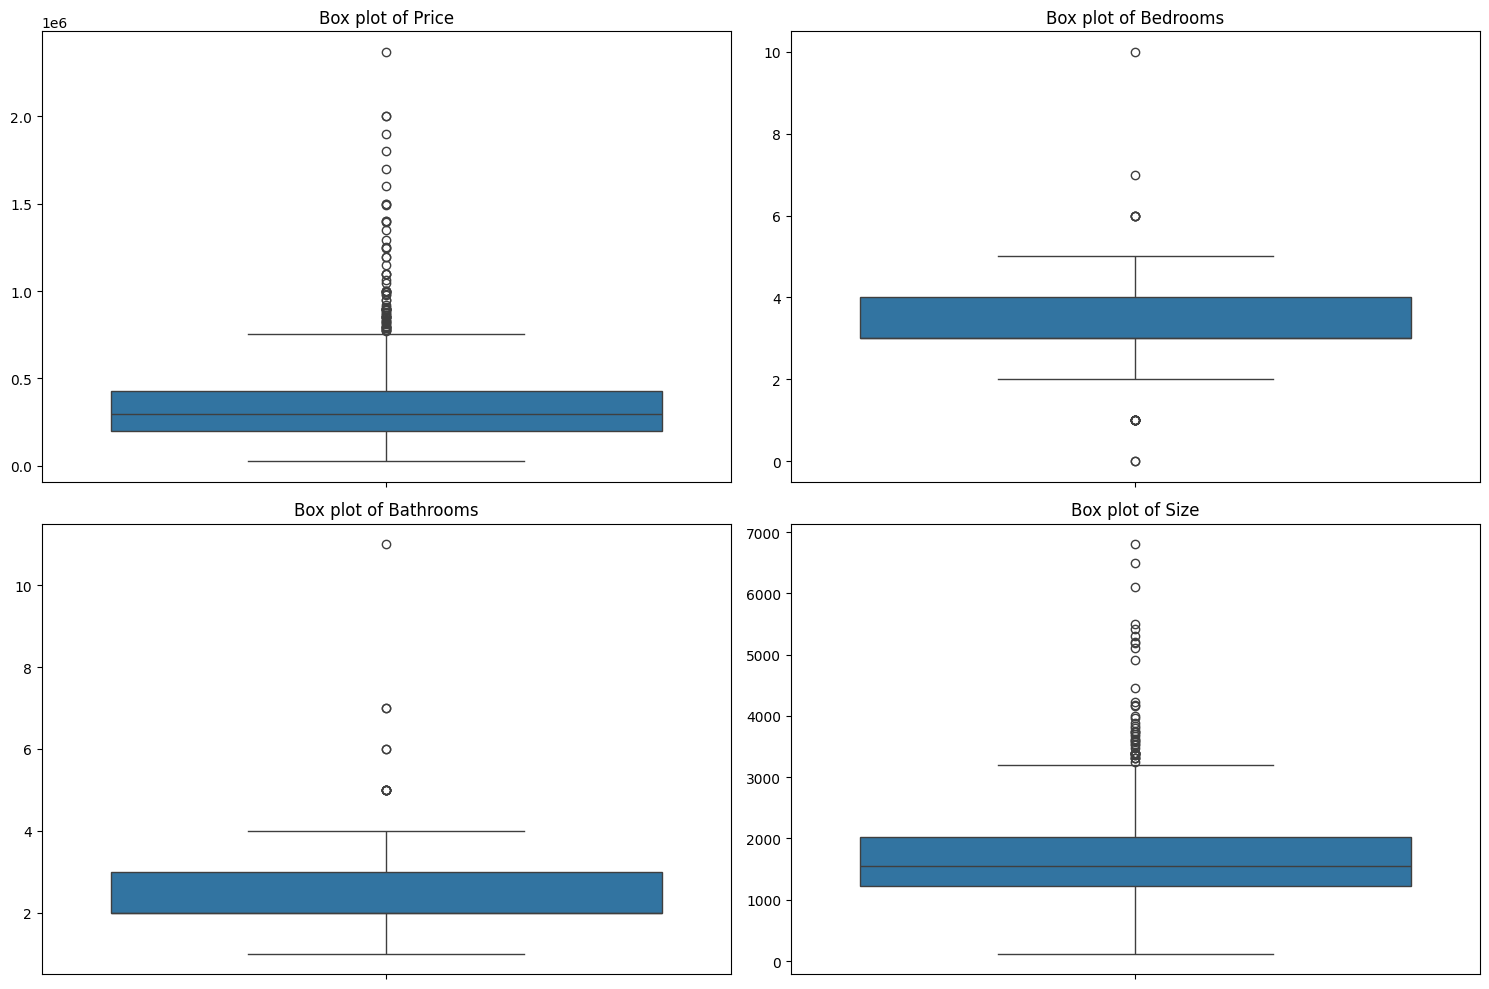

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for outlier detection, excluding 'MLS' as it's an identifier
numerical_cols = ['Price', 'Bedrooms', 'Bathrooms', 'Size']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)  # Arrange plots in a 2x2 grid
    sns.boxplot(y=df_real_noduplicates[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel('') # Remove y-label to avoid clutter
plt.tight_layout()
plt.show()


Outliers here are shown via the hollow circles on the box plots. For the bathroom and bedroom tabs, I agree that these values would be outliers since the boxes are tight and the numbers are infrequent. However, for price and size, I believe some of the outlying values are actually just large tails in the data. Unlike the bathroom/bedroom plots, there are quite a few points in each, so, aside from the furthest points, these values are not outliers.

#### Check the varabble with the business context to screen for outliers.

Check price

In [9]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'Price'
Q1_price = df_real_noduplicates['Price'].quantile(0.25)
Q3_price = df_real_noduplicates['Price'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR_price = Q3_price - Q1_price

# Define the upper and lower bounds for outlier detection
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

# Identify potential outliers in 'Price'
outliers_price = df_real_noduplicates[(df_real_noduplicates['Price'] < lower_bound_price) | (df_real_noduplicates['Price'] > upper_bound_price)]

print(f"Q1 for Price: {Q1_price}")
print(f"Q3 for Price: {Q3_price}")
print(f"IQR for Price: {IQR_price}")
print(f"Lower Bound for Price outliers: {lower_bound_price}")
print(f"Upper Bound for Price outliers: {upper_bound_price}")

print(f"\nNumber of potential price outliers: {len(outliers_price)}")
print("\nPotential Price Outliers (first 5 rows if any):")
print(outliers_price.head())

Q1 for Price: 199000.0
Q3 for Price: 428450.0
IQR for Price: 229450.0
Lower Bound for Price outliers: -145175.0
Upper Bound for Price outliers: 772625.0

Number of potential price outliers: 70

Potential Price Outliers (first 5 rows if any):
       MLS       Location    Price  Bedrooms  Bathrooms  Size      Status
0   132842  Arroyo Grande   795000         3          3  2371  Short Sale
3   135712      Morro Bay   909000         4          4  3540  Short Sale
8   137159      Morro Bay   999000         4          3  3360  Short Sale
20  140077      Morro Bay  1100000         4          3  4168  Short Sale
21  140080        Cayucos  1500000         3          3  3880  Short Sale


We will stop cleaning data in this example. In homework#1, you will practice data cleaning with other variables in this data.

### Overall data summary

In [10]:
print("### Data Structure Info ###")
print(df_real_noduplicates.info())

print("\n### Statistical Summary ###")
display(df_real_noduplicates.describe(include='all'))

### Data Structure Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779 entries, 0 to 778
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   MLS        779 non-null    int64 
 1   Location   779 non-null    object
 2   Price      779 non-null    int64 
 3   Bedrooms   779 non-null    int64 
 4   Bathrooms  779 non-null    int64 
 5   Size       779 non-null    int64 
 6   Status     779 non-null    object
dtypes: int64(5), object(2)
memory usage: 42.7+ KB
None

### Statistical Summary ###


,MLS,Location,Price,Bedrooms,Bathrooms,Size,Status
count,779.000000,779,7.790000e+02,779.000000,779.000000,779.000000,779
unique,NaN,34,NaN,NaN,NaN,NaN,3
top,NaN,Santa Maria-Orcutt,NaN,NaN,NaN,NaN,Short Sale
freq,NaN,278,NaN,NaN,NaN,NaN,516
mean,151216.119384,NaN,3.734095e+05,3.138639,2.350449,1748.340180,NaN
std,3937.650248,NaN,2.822011e+05,0.853713,0.840283,809.053205,NaN
min,132842.000000,NaN,2.650000e+04,0.000000,1.000000,120.000000,NaN
25%,149920.500000,NaN,1.990000e+05,3.000000,2.000000,1217.500000,NaN
50%,152570.000000,NaN,2.950000e+05,3.000000,2.000000,1550.000000,NaN
75%,154160.000000,NaN,4.284500e+05,4.000000,3.000000,2024.000000,NaN


1. Data Structure
Total Records: There are 779 properties in the dataset.
Columns: The dataset contains 7 columns: MLS (ID), Location, Price, Bedrooms, Bathrooms, Size (sq ft), and Status.
Data Quality: All 779 entries are non-null, meaning there is no missing data in this dataset.

2. Statistical Overview
Price: The average property price is approximately $373,409**, with a wide range from a minimum of **$$373,409**, with a wide range from a minimum of **$26,500 to a maximum of $2,369,000.
Property Features:
The typical house has 3 bedrooms and 2 bathrooms.
The average size is 1,748 sq ft, though sizes vary significantly from 120 sq ft to 6,800 sq ft.
Location & Status:
Santa Maria-Orcutt is the most frequent location, appearing 278 times.
Short Sale is the most common transaction status, accounting for 516 of the entries.

### Visualization

You prompt AI to build a specific chart. The followings are basic visuals.

*  Boxplot
*  Scatter plot
*  Histogram
*  Line plot
*  Bar plot


If you are not sure what chart to build, you may prompt AI to give you some basic visuals to start with.


**Sample prompt:**

Build some visuals for df_real_clean and summarize the key findings.

********************************

The next section Task is sample analysis generated by AI.

Let's pick histogram as an example and think about how to improve from the basics.

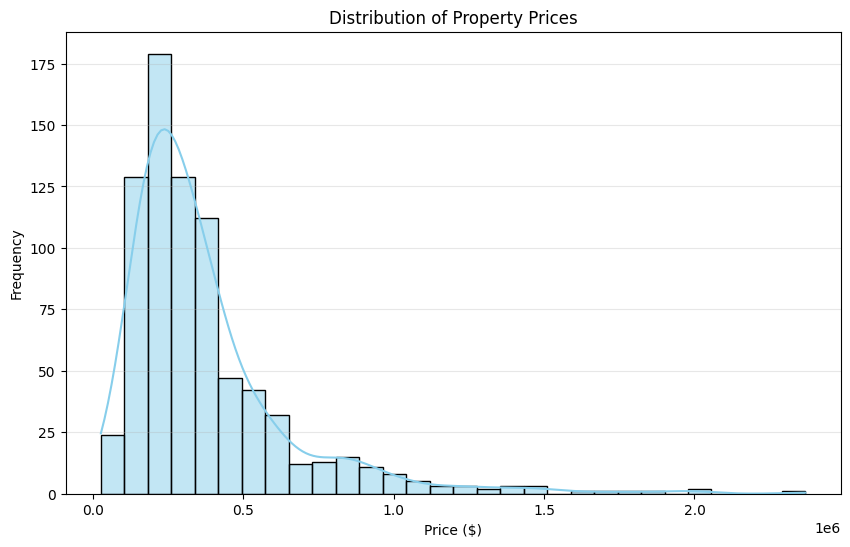

### Key Findings from Price Distribution ###
1. The distribution is heavily right-skewed, indicating that while most properties are moderately priced, there are a few very high-priced luxury estates.
2. The peak of the distribution (the mode) appears to be in the $200,000 to $400,000 range.
3. The long tail extending toward $2 million confirms the presence of the high-value properties we discussed as statistical outliers.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram for the Price column
plt.figure(figsize=(10, 6))
sns.histplot(df_real_noduplicates['Price'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Property Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Summary of key findings
print("### Key Findings from Price Distribution ###")
print(f"1. The distribution is heavily right-skewed, indicating that while most properties are moderately priced, there are a few very high-priced luxury estates.")
print(f"2. The peak of the distribution (the mode) appears to be in the $200,000 to $400,000 range.")
print(f"3. The long tail extending toward $2 million confirms the presence of the high-value properties we discussed as statistical outliers.")

# Stucture visualization based on business context


## Historgram

Notice that in the data there are three types of transactions: regular, short sale, and foreclosure.

Quick questions: What is the main difference among these transaction types, and what impact do they have on price?

Let's build the price histogram again, but separate the analysis for these three transaction types.

**Sample prompt: **
Build histograms of price, separate and color the histogram by transaction type, and dodge the histogram bars.

Note: Using the `dodge` position makes it easier to compare histogram bars across categories because all bars are positioned side by side.



Let's filter the `df_real_clean` DataFrame to remove the extreme high prices (e.g., above the 99th percentile) to get a clearer view of the distribution for the majority of properties. Then, we will regenerate the histogram.

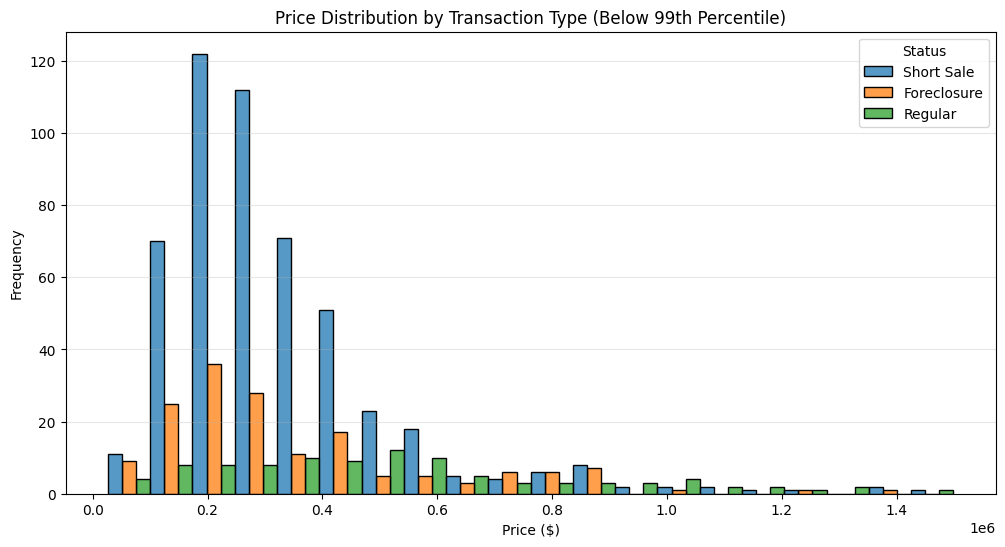

Summary: The histogram now excludes properties priced above $1,499,220.00. This provides a clearer view of the main market segments, showing how Short Sales and Foreclosures compare to Regular listings in volume and price range.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the 99th percentile for Price
price_99th = df_real_noduplicates['Price'].quantile(0.99)

# Filter the data to remove extreme outliers
df_filtered = df_real_noduplicates[df_real_noduplicates['Price'] <= price_99th]

# Create the dodged histogram
plt.figure(figsize=(12, 6))
sns.histplot(data=df_filtered, x='Price', hue='Status', multiple='dodge', bins=20)
plt.title('Price Distribution by Transaction Type (Below 99th Percentile)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Summary: The histogram now excludes properties priced above ${price_99th:,.2f}. This provides a clearer view of the main market segments, showing how Short Sales and Foreclosures compare to Regular listings in volume and price range.")

## Boxplot

Similarly, we can also compare the price distribution of these three types using box plots.

Sample prompt:

Build boxplots of price, separate and color the box by status.

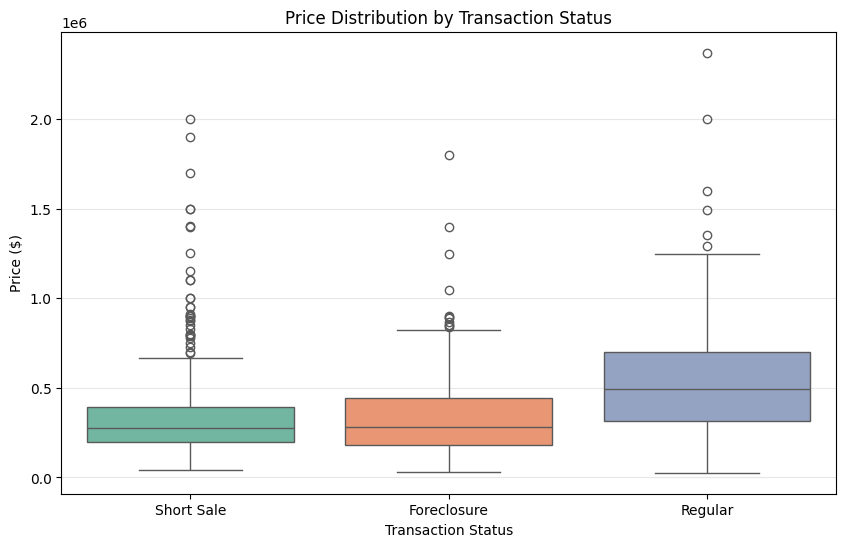

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot for Price categorized and colored by Status
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_real_noduplicates, x='Status', y='Price', hue='Status', palette='Set2')
plt.title('Price Distribution by Transaction Status')
plt.xlabel('Transaction Status')
plt.ylabel('Price ($)')
plt.grid(axis='y', alpha=0.3)
plt.show()

# **Homework 1**

**Due**

By the end of 01/16/2026

**Assignment Instructions**

* Follow the steps we discussed in class to develop the analysis and answer all questions.

* Write down your prompt either in a new text box or as a line comment in the code box.

* Read the code generated by AI. Focus on the logical flow.

* If necessary, make adjustment and prompt AI to update the code.

**Submission Requirements:**

&nbsp; &nbsp; Convert your completed notebook into a PDF or HTML report.

&nbsp; &nbsp; Submit the report on Brightspace before the deadline.

**Grading Rubric**

Assignments must be complete (all questions answered) and submitted on time. The rubric emphasizes mastery of programming details, as precision is critical in coding.

*  5 – Excellent: Strong effort. Code runs without errors. Explanations align with the results produced.

*  4 – Good: Strong effort. Code contains errors, and some explanations are inconsistent with the results.

*  2 – Fair: Limited effort. Multiple major errors (e.g., incorrect functions, inappropriate features, or results far off expectations). Incomplete work, insufficient explanation, or missing report.

Late Submissions:

*  Up to 24 hours late → 50% of the original grade.

*  More than 24 hours late → 0 points.



### Q1. Follow our class example. In class, we investigated `price` for data cleaning. Please check two other variables, `bathroom` and `bedroom`, for potential outliers. Report your findings and explain why you consider those values outliers.

In [14]:
import pandas as pd

# Define the variables to check
vars_to_check = ['Bathrooms', 'Bedrooms']

for var in vars_to_check:
    Q1 = df_real_noduplicates[var].quantile(0.25)
    Q3 = df_real_noduplicates[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_real_noduplicates[(df_real_noduplicates[var] < lower_bound) | (df_real_noduplicates[var] > upper_bound)]

    print(f"--- Outlier Analysis for {var} ---")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)}")
    if not outliers.empty:
        display(outliers.sort_values(by=var, ascending=False))
    print("\n")

--- Outlier Analysis for Bathrooms ---
Lower Bound: 0.5, Upper Bound: 4.5
Number of outliers: 12


,MLS,Location,Price,Bedrooms,Bathrooms,Size,Status
639,154359,Atascadero,699000,10,11,4905,Short Sale
201,150143,Arroyo Grande,1499000,5,7,6800,Short Sale
443,152999,Los Osos,1249000,6,7,5103,Foreclosure
419,152809,Paso Robles,695000,5,6,3750,Short Sale
702,154463,San Luis Obispo,2369000,5,6,4174,Regular
111,147249,Atascadero,890000,4,5,4229,Foreclosure
75,145471,Nipomo,325000,7,5,2688,Short Sale
45,142977,Templeton,1150000,4,5,5500,Short Sale
125,147876,Bradley,499000,4,5,3400,Short Sale
407,152768,Avila Beach,1999000,4,5,5307,Short Sale




--- Outlier Analysis for Bedrooms ---
Lower Bound: 1.5, Upper Bound: 5.5
Number of outliers: 19


,MLS,Location,Price,Bedrooms,Bathrooms,Size,Status
639,154359,Atascadero,699000,10,11,4905,Short Sale
75,145471,Nipomo,325000,7,5,2688,Short Sale
443,152999,Los Osos,1249000,6,7,5103,Foreclosure
731,154496,Atascadero,425000,6,3,2628,Regular
457,153119,Santa Maria-Orcutt,339900,6,3,2053,Foreclosure
494,153480,Atascadero,399000,6,3,2628,Foreclosure
76,145726,Santa Maria-Orcutt,119000,1,1,900,Short Sale
82,146110,Atascadero,199000,1,1,712,Short Sale
348,152131,Atascadero,187500,1,1,594,Short Sale
131,148318,Los Osos,99000,1,1,538,Short Sale


When we compare the objective IQR analysis to the subjective business context, we see that larger outliers that would be excluded under IQR actually shed light into the luxury home market. These values should **not** be excluded from the dataset. However, some entries (like MLS 154359) should remain excluded since they do not even close to resemble the dataset (nearly double the closest home size in terms of bathroom and bedroom).

### Q2 Drop the outliers we identified in class and the ones you identified in the previous question. As we did in class, and given the AI‑drafted analysis, create a scatter plot based on the business context. What prompt would you send to your AI? Briefly explain the finding from the visual.

<Figure size 1200x700 with 0 Axes>

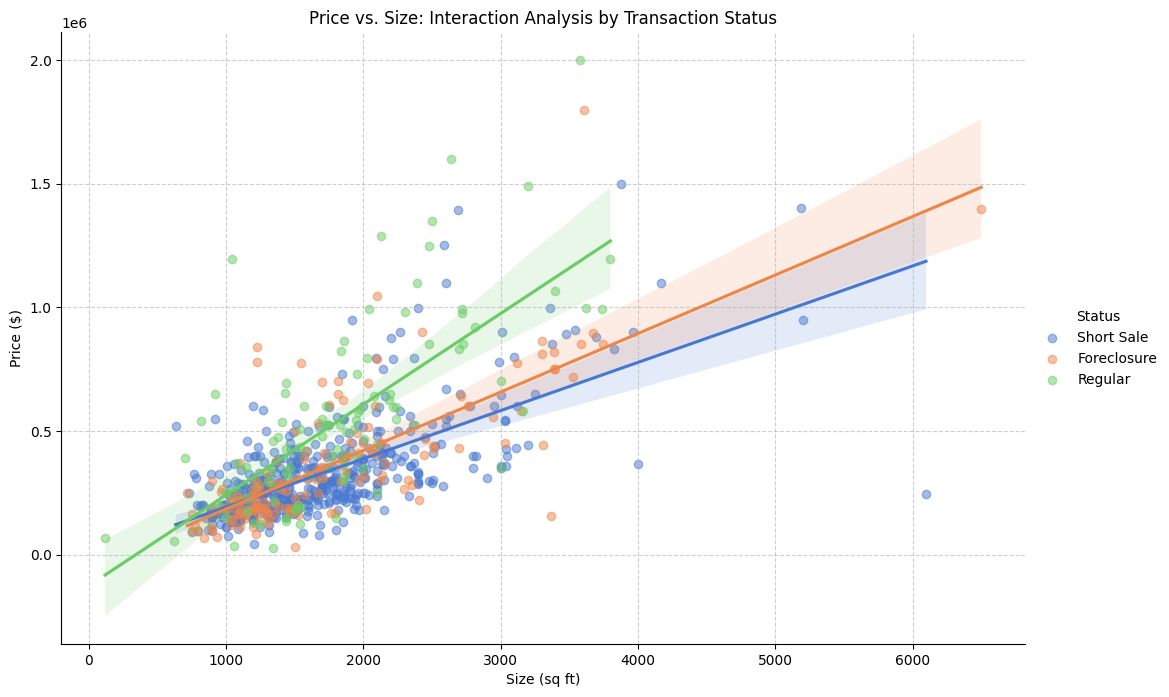

Correlation (R) by Transaction Status:
Short Sale: R = 0.66
Foreclosure: R = 0.74
Regular: R = 0.70


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Filter the dataframe to remove statistical outliers for Bathrooms and Bedrooms
df_clean = df_real_noduplicates[
    (df_real_noduplicates['Bathrooms'] <= 4.5) &
    (df_real_noduplicates['Bedrooms'] <= 5.5) &
    (df_real_noduplicates['Bedrooms'] >= 1.5)
]

# Generate the Scatter Plot with separate trendlines for each Status
plt.figure(figsize=(12, 7))

# lmplot is better for multiple trendlines, but to maintain the style we use regplot in a loop or implot
sns.lmplot(data=df_clean, x='Size', y='Price', hue='Status',
           palette='muted', ci=95, height=7, aspect=1.5,
           scatter_kws={'alpha': 0.5})

plt.title('Price vs. Size: Interaction Analysis by Transaction Status')
plt.xlabel('Size (sq ft)')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calculate correlation for each group to see the strength within types
print("Correlation (R) by Transaction Status:")
for status in df_clean['Status'].unique():
    subset = df_clean[df_clean['Status'] == status]
    r, _ = stats.pearsonr(subset['Size'], subset['Price'])
    print(f"{status}: R = {r:.2f}")

This scatterplot shows us the correlation between property size and price. I've added a trendline to visualize said correlation. Considering R equals 0.6650 here, we cvan determine that this correlation is directional but not concrete. The two variables are moderately correlated and we could attempt to establish a model on the basis of this.

I tried this by setting up an interaction model based on transaction type. Here, we can see that all three lines are moderately correlated (see R values below graph), and the lines do vary. This confirms what the business context tells us: a regular sale would allow the seller to capitalize on sale value better than a foreclosure/short sale scenario.

We obviously don't observe this statistically, but this insight could help you argue that there is a positive correlation between buyer control of a home sale and the price of said house.

### Q3 Drop the outliers we identified in class and the ones you identified in the previous question. As we did in class, and given the AI‑drafted analysis, create a bar graph based on the business context. What prompt would you send to your AI? Briefly explain the finding from the visual.

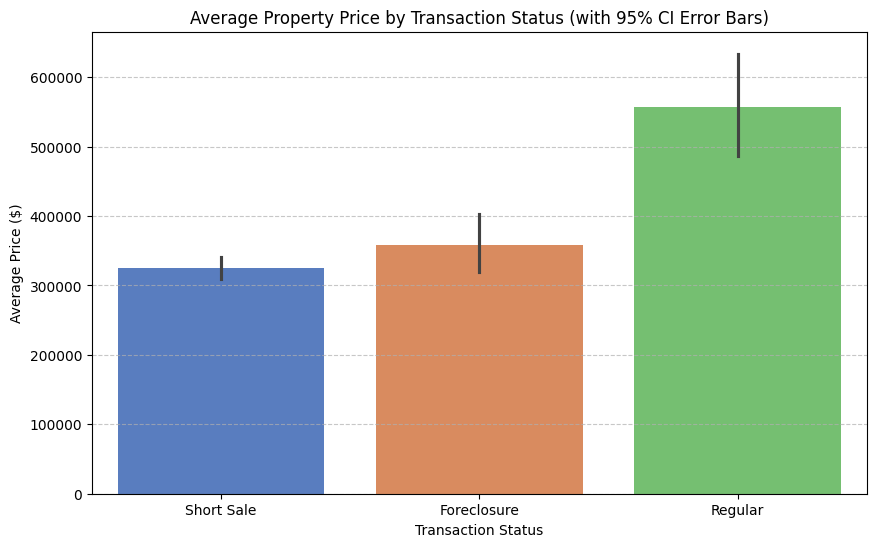

Average Prices by Status:
Status
Regular        557344.887755
Foreclosure    358145.612903
Short Sale     325620.614458
Name: Price, dtype: float64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average price by status for the bar plot with error bars
plt.figure(figsize=(10, 6))
# Using errorbar='ci' (or 95) to show the confidence interval range
sns.barplot(data=df_clean, x='Status', y='Price', estimator='mean', hue='Status', palette='muted', errorbar=('ci', 95))

plt.title('Average Property Price by Transaction Status (with 95% CI Error Bars)')
plt.xlabel('Transaction Status')
plt.ylabel('Average Price ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Brief finding explanation
avg_prices = df_clean.groupby('Status')['Price'].mean().sort_values(ascending=False)
print("Average Prices by Status:")
print(avg_prices)

This bar graph confirms the analysis I made in the prior text: homes sell for more when the seller has more control.

This makes complete sense the power in the sale shifts across all three. A regular sale would surely involve a deeper realtor negotiation with incentive structures included as well. A short sale or foreclosure (both quite close here), would each be expedited and hasty processes with no room nor power to get a higher price.